In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

from app.utils.gpt_parser import canonical_portfolio
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from app.core.calculations.returns.calculator import ReturnsCalculator, PortfolioReturnsCalculator
from app.core.calculations.performance.calculator import PerformanceCalculator
from app.core.calculations.risk.calculator import RiskCalculator
from app.repositories.price_data import get_price_data_daily, get_dividends_series
from app.repositories.price_data import fetch_bulk_price_data_for_tickers
import matplotlib.pyplot as plt
# Fetch industry and sub-industry data for all tickers
from app.db.core.db_config import MarketSession, ProphitAltsSession
from app.db.core.models.market_data_models import Ticker
from app.core.agentic_framework.tool_lib.portfolio_tools.performance import calculate_portfolio_performance



In [2]:

x1 = {"portfolio": [{"ticker": "NVDA", "allocation": 0.08, "position": "long", "changes_from_original": "Increased (0.065 to 0.08) to anchor for growth and alpha."}, {"ticker": "APP", "allocation": 0.05, "position": "long", "changes_from_original": "Increased (0.042 to 0.05) based on top risk-adjusted return."}, {"ticker": "AVGO", "allocation": 0.05, "position": "long", "changes_from_original": "Increased (0.034 to 0.05) for quality/growth balance."}, {"ticker": "PLTR", "allocation": 0.03, "position": "long", "changes_from_original": "Slight trim (0.027 to 0.03) for balanced tech exposure."}, {"ticker": "BSX", "allocation": 0.05, "position": "long", "changes_from_original": "Proportional trim (0.051 to 0.05) for risk parity."}, {"ticker": "NRG", "allocation": 0.04, "position": "long", "changes_from_original": "Reduced slightly (0.055 to 0.04) for scenario sizing."}, {"ticker": "JPM", "allocation": 0.04, "position": "long", "changes_from_original": "Adjusted (0.043 to 0.04) for risk budget and financials mix."}, {"ticker": "EQIX", "allocation": 0.04, "position": "long", "changes_from_original": "Right-sized (0.081 to 0.04) to reduce REIT/correlation risk."}, {"ticker": "SGDM", "allocation": 0.03, "position": "long", "changes_from_original": "Up (0.016 to 0.03) to keep gold/hedge exposure robust."}, {"ticker": "SLVR", "allocation": 0.03, "position": "long", "changes_from_original": "Down (0.036 to 0.03) to balance commodities within risk budget."}, {"ticker": "GREK", "allocation": 0.025, "position": "long", "changes_from_original": "Minor increase (0.021 to 0.025) for EM/momentum tilt."}, {"ticker": "VCSH", "allocation": 0.03, "position": "long", "changes_from_original": "No significant change from previous allocation."}, {"ticker": "IGSB", "allocation": 0.03, "position": "long", "changes_from_original": "No significant change from previous allocation."}, {"ticker": "LLY", "allocation": 0.025, "position": "long", "changes_from_original": "Added: Best-in-class pharma, high Sharpe, growth, and alpha potential added for defensive growth quality."}, {"ticker": "CL", "allocation": 0.02, "position": "long", "changes_from_original": "Added: Ultra-low beta/high ROE, major staple added for drawdown minimization."}, {"ticker": "CLX", "allocation": 0.02, "position": "long", "changes_from_original": "Added: High ROE, defensive blue-chip replaces high-beta/volatility exposures."}, {"ticker": "KMB", "allocation": 0.015, "position": "long", "changes_from_original": "Added: Low beta, quality staple, improves defensive tilt and lowers overall risk."}]}
# portfolio = {'APP': {'allocation': 0.0006, 'position': 'long'}, 'ARM': {'allocation': 0.0035, 'position': 'long'}, 'AVGO': {'allocation': 0.0222, 'position': 'long'}, 'BSX': {'allocation': 0.0792, 'position': 'long'}, 'CEG': {'allocation': 0.0068, 'position': 'long'}, 'CMS': {'allocation': 0.1169, 'position': 'long'}, 'DGNX': {'allocation': 0.0034, 'position': 'long'}, 'EIS': {'allocation': 0.082, 'position': 'long'}, 'EQIX': {'allocation': 0.0721, 'position': 'long'}, 'EXOD': {'allocation': 0.0158, 'position': 'long'}, 'JPM': {'allocation': 0.075, 'position': 'long'}, 'MU': {'allocation': 0.0039, 'position': 'long'}, 'NLR': {'allocation': 0.0509, 'position': 'long'}, 'NRG': {'allocation': 0.0204, 'position': 'long'}, 'NVDA': {'allocation': 0.0233, 'position': 'long'}, 'PLTR': {'allocation': 0.0072, 'position': 'long'}, 'SGDM': {'allocation': 0.08, 'position': 'long'}, 'SLVR': {'allocation': 0.0515, 'position': 'long'}, 'STAG': {'allocation': 0.0819, 'position': 'long'}, 'TRNO': {'allocation': 0.0737, 'position': 'long'}, 'VCSH': {'allocation': 0.1298, 'position': 'long'}}
# portfolio = canonical_portfolio(x)
x = [
  {
    "ticker": "BJ",
    "position": "long",
    "thesis": "BJ’s Wholesale Club is a membership-driven retail model leveraging private label economics and operational efficiencies. Strong ROE (7.2-7.6%), steady operating margins (~4%) and industry-leading free cash flow conversion underpin financial durability. Its high member renewal rates, historical inflation resilience, and focus on value positioning encourage robust customer traffic despite sector headwinds. Membership renewal and inflation hedging further reinforce downside risk protection.",
    "key_drivers": "1) Resilient membership economics and value focus; 2) Outperformance in both pro-cyclical and recessionary periods due to club model; 3) Consistent margin and FCF generation; 4) High private label mix; 5) Operational scale and cost control; 6) Defensive sector exposure with low beta (0.14); 7) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.052
  },
  {
    "ticker": "CAG",
    "position": "long",
    "thesis": "Conagra offers contrarian value at a discount to peers, supported by visible operating margin recovery and sequential improvements from pricing/cost actions. The company has low leverage and is trading at PE multiples that reflect cyclical troughs. Defensive SKU breadth and strong brand moat provide stability during volatile packaging and input cycles.",
    "key_drivers": "1) Improving sequential margin/ROIC; 2) Attractive valuation (PE ~10-21); 3) Margins recovering from inflation pass-through; 4) Strong product brand/retail relationships; 5) Broad portfolio with stable consumer staples demand; 6) Defensive low beta (0.07); 7) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.05
  },
  {
    "ticker": "CCEP",
    "position": "long",
    "thesis": "Coca-Cola Europacific Partners, the premier KO bottler, excels in shelf space, operating efficiency, and pricing power. High gross and operating margins, significant scale, and regional/localization strategies drive high quality compounder status. Strong track record of low volatility and defensive returns.",
    "key_drivers": "1) Premium bottling/distribution rights; 2) Above-average margin and FCF yield; 3) Deep pricing power; 4) Risk mitigation via scale and shelf presence; 5) Advantageous localization/shelf optimization strategies; 6) Defensive, low beta (0.30); 7) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.052
  },
  {
    "ticker": "BG",
    "position": "long",
    "thesis": "Bunge is a leading agricultural processor/originator trading at a discount to normalized mid-cycle economics. Robust balance sheet, strategic positioning in global commodity flows, and effective risk management drive strong normalized FCF. Positive recent momentum and effective capital returns support upside potential.",
    "key_drivers": "1) Cash generator with proven hedging strategies; 2) Underappreciated normalized earnings power; 3) Conservative capital returns (buyback/dividend); 4) Attractive value (PE ~7.7-12.7); 5) Good defensive beta (0.39); 6) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.053
  },
  {
    "ticker": "CL",
    "position": "long",
    "thesis": "Colgate-Palmolive offers a durable compounder profile with industry-leading gross margin (>35%), strong market share in oral care, consistent FCF, and modest leverage. Entry after a pullback offers an attractive combination of defensive quality and potential upside from GM expansion.",
    "key_drivers": "1) Dominant brand in oral care; 2) Stable, high margin model; 3) FCF compounding; 4) Defensive sector characteristics; 5) Low to moderate operating risk; 6) Support: get_ticker_fundamental_data.",
    "allocation": 0.052
  },
  {
    "ticker": "CHD",
    "position": "short",
    "thesis": "Church & Dwight faces aging brand risks, rising input costs, and promotional spending pressures—all at a premium relative to slower growth prospects. Recent performance is poor and profitability is susceptible to further compression, while the current share price discounts a return to previous margin highs.",
    "key_drivers": "1) Weak risk-adjusted returns; 2) Premium valuation relative to sector; 3) Margin headwinds from promo intensity; 4) Regulatory cost exposure; 5) Negative alpha; 6) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.04
  },
  {
    "ticker": "CELH",
    "position": "short",
    "thesis": "Celsius Holdings’ astronomical valuation and excessive volatility (beta ~1.0, volatility 64%) present large risks as growth decelerates. Recent rating downgrades and shelf reset risk undermine confidence in continued momentum. High embedded growth expectations, plus competition and de-rating risk, skew risk/reward sharply negative.",
    "key_drivers": "1) High price/book, PE, and volatility; 2) Growth normalization; 3) Increasing competition; 4) Ratings/target cut cycle; 5) Sensitivity to shelf resets/promos; 6) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.04
  },
  {
    "ticker": "COCO",
    "position": "short",
    "thesis": "The Coca-Cola Company faces mean reversion risk after outsized momentum. Valuation is stretched (high PE/PB), and shelf/nearly saturated category/retailer private label threat poses downside risk. High beta and volatility compound downside on earnings disappointment or sector rotation.",
    "key_drivers": "1) Rich valuation; 2) Rising competitive risk; 3) Retailer shelf reset incentive; 4) High price momentum at risk of reversal; 5) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.04
  },
  {
    "ticker": "DG",
    "position": "long",
    "thesis": "Dollar General is a trade-down beneficiary with attractive value (PE 12-14) and a visible margin recovery plan. Management’s supply chain/operating improvements are expected to drive margin repair into 2026. While negative beta remains a concern, DG provides unique factor diversification in a low-beta portfolio.",
    "key_drivers": "1) Trade-down/resilient demand in value retail; 2) Self-help margin initiatives; 3) Attractive forward valuation; 4) Low correlation to consumer cyclicality; 5) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.052
  },
  {
    "ticker": "CLX",
    "position": "short",
    "thesis": "Clorox bears the dual burden of excessive leverage (debt/equity 9-110x) and negative returns. Its weak ROE/ROA and continual margin fragility present compelling grounds for a short, particularly as pandemic windfalls fade.",
    "key_drivers": "1) High leverage; 2) Weak operational efficiency; 3) Deteriorating fundamentals; 4) Recent negative momentum; 5) High beta (0.26); 6) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.04
  },
  {
    "ticker": "COST",
    "position": "short",
    "thesis": "Costco’s stellar operations are fully priced in, with best-in-class operational track record offset by staggeringly high PE (59-66) and P/B (16-18). Valuation is unsustainable should the business see even temporary slowing or margin reversion.",
    "key_drivers": "1) Highest valuation risk in staples space; 2) Beta 0.62; 3) Modest margin benefits fading; 4) Macro headwinds not reflected in price; 5) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.04
  },
  {
    "ticker": "COTY",
    "position": "short",
    "thesis": "Coty’s consistent net losses, highly negative momentum, and high beta/volatility with minimal balance sheet resilience make it an ideal short. Downside is supported by poor quality, and inability to turn portfolio rationalization into returns.",
    "key_drivers": "1) Consistent net losses and negative cash flow; 2) High downside volatility beta (1.05); 3) Negative 1Y and 3Y returns; 4) Margin erosion; 5) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.04
  },
  {
    "ticker": "EPC",
    "position": "long",
    "thesis": "Edgewell Personal Care is a rare value in personal care (PE 9.6-13, P/B <1) with steadily improving margins via self-help/brand momentum (Sun, Hawaiian Tropic, and international). Despite sector headwinds, recovery in ROIC and balance sheet supports exposure for staple diversification.",
    "key_drivers": "1) Valuation discount; 2) Self-help and productivity program execution; 3) Improving gross/operating margins (42-44%); 4) Defensive FCF profile; 5) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.05
  },
  {
    "ticker": "FIZZ",
    "position": "short",
    "thesis": "National Beverage Corp. is a high-multiple, premium beverage with modest moat and brand power. Strong past ROIC but downtrending 1Y returns, negative alpha, and overvaluation justify a short for mean reversion risk and core staple factor exposure.",
    "key_drivers": "1) Downside momentum (-16% 1Y total return); 2) Overstretched multiples (PE ~19-22); 3) Brand/volume risk; 4) Beta 0.22; 5) Limited scale outside brand; 6) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.04
  },
  {
    "ticker": "FRPT",
    "position": "short",
    "thesis": "Freshpet presents an unattractive risk/reward following severe drawdown (-64% 1Y return), high volatility, and mean reversion risk. Current multiples and business swings are not justified by fundamentals.",
    "key_drivers": "1) Very high valuation; 2) Negative 1Y and 3Y returns; 3) High volatility; 4) Category risk; 5) Unstable margin performance; 6) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.04
  },
  {
    "ticker": "GIS",
    "position": "long",
    "thesis": "General Mills brings stability and margin resilience to the portfolio. Although momentum is out of favor, their low beta, recurring FCF, and robust balance sheet enhance overall portfolio defensiveness.",
    "key_drivers": "1) Margin and cash flow stability; 2) Broad product mix; 3) Defensive sector exposure; 4) Low beta (0.01); 5) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.052
  },
  {
    "ticker": "HSY",
    "position": "short",
    "thesis": "Hershey faces margin compression from cocoa spikes (2024-25), rising cost complexity, and softening volume. Despite stability, deteriorating profitability and high valuation (PE up to 134x) support a short position ahead of cyclical headwinds.",
    "key_drivers": "1) Margin compression drivers; 2) Deteriorating trend in profit/loss; 3) Cocoa cost risk; 4) Elevated sector multiples; 5) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.04
  },
  {
    "ticker": "INGR",
    "position": "long",
    "thesis": "Ingredion offers a cash-generative, resilient growth profile (PE ~11), with considerable margin and pricing power. Regulatory tailwinds support ingredient and specialty exposure. Stable positive alpha and moderate beta ensure robust, defensive long positioning.",
    "key_drivers": "1) Stable revenue and margin mix (operating ~15%); 2) Moderate leverage, solid cash flow; 3) Regulatory tailwind (EUDR/FSMA); 4) Low beta (0.37); 5) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.052
  },
  {
    "ticker": "IPAR",
    "position": "long",
    "thesis": "Inter Parfums exhibits quality compounder characteristics in prestige fragrance, with an expanding license base, growing international platform, and margin compounding via asset-light execution. Strong brand relationships enable pricing power but, near-term momentum is challenged. Appropriate for modest allocation.",
    "key_drivers": "1) Pricing power; 2) Tariff and risk mitigation strategies; 3) Diversified brand pipeline; 4) FCF support for continued growth; 5) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.052
  },
  {
    "ticker": "KDP",
    "position": "long",
    "thesis": "Keurig Dr Pepper is a large-scale, diversified beverage franchise stabilizing from a cyclical trough. Margin normalization path and moderate beta (0.15) make for a defensive, low-vol risk allocation.",
    "key_drivers": "1) Underappreciated mean reversion in margins; 2) Diversified product exposure; 3) Margin of safety in defensive beverage positioning; 4) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.052
  },
  {
    "ticker": "KLG",
    "position": "short",
    "thesis": "Kellogg faces headwinds from portfolio mix, pricing power erosion, and competitive threat from private label. Volatile returns, high price/book (3.9-5.1), and low profitability increase mean reversion risk.",
    "key_drivers": "1) Portfolio pressure from value and private label; 2) Negative return trend; 3) High beta risk; 4) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.04
  },
  {
    "ticker": "KMB",
    "position": "long",
    "thesis": "Kimberly-Clark offers robust margin and cash flow defensiveness for the staples sector. Strong historical outperformance, low beta (0.13), and a thick FCF cushion make KMB a cornerstone defensive allocation.",
    "key_drivers": "1) High cash flow conversion; 2) Positive 3Y return trend; 3) Low/defensive sector beta; 4) Recurring product demand; 5) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.052
  },
  {
    "ticker": "KO",
    "position": "long",
    "thesis": "Coca-Cola’s global beverage franchise is the premier low-volatility core holding for staples, benefiting from diversified global operations, durable pricing power, high margin/FCF, and unmatched sector resilience.",
    "key_drivers": "1) Superior shelf and pricing power; 2) Consistent margin expansion; 3) Defensive, low beta (0.09); 4) ESG-driven packaging strategies; 5) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.052
  },
  {
    "ticker": "MO",
    "position": "long",
    "thesis": "Altria sits at a valuation trough with resilient pricing and best-in-class cash conversion. Menthol regulatory risks and nicotine caps are distant. Recent momentum improvement, high yield, and low beta make MO a core quality/defensive long.",
    "key_drivers": "1) Defensive sector leader in U.S. comb tobacco; 2) Strong dividend and cash return; 3) Low beta, high Sharpe and alpha; 4) Regulatory risk over-discounted; 5) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.052
  },
  {
    "ticker": "OLPX",
    "position": "short",
    "thesis": "Olaplex’s volatility, persistent negative returns, and high beta (1.44) reflect deteriorating operational performance and multiple expansion risk. No sign of a floor on margin/brand protection.",
    "key_drivers": "1) High beta and volatility; 2) Downward price/margin momentum; 3) Litigation/strategy overhang; 4) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.04
  },
  {
    "ticker": "REYN",
    "position": "long",
    "thesis": "Reynolds Consumer Products is a defensive FCF-rich holding in household packaging. Despite weak recent returns and only modest operating margins, the low beta (0.24) and business defensiveness make it a core sector holding.",
    "key_drivers": "1) Defensive sector exposure; 2) Reasonable FCF and operational leverage; 3) Recurring packaging demand; 4) Stable balance sheet; 5) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.052
  },
  {
    "ticker": "RLX",
    "position": "long",
    "thesis": "RLX Technology offers deep value in Chinese ENDS with immense net cash cushion, high net margin, and above-market alpha. Risk diversification and strong 1Y returns recommend tactical portfolio inclusion.",
    "key_drivers": "1) Deep value metrics; 2) High net margin; 3) Exceptional balance sheet; 4) Strong 1Y return and alpha; 5) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.052
  },
  {
    "ticker": "SFM",
    "position": "short",
    "thesis": "Sprouts Farmers Market faces significant trade-down/valuation risk, high leverage, and negative returns. Beta of 0.63 and past mean reversion after pandemic. A credible short for risk management.",
    "key_drivers": "1) Elevated leverage; 2) Subpar 1Y trending total/share returns; 3) Vulnerable at upper valuation; 4) Margin compression risk; 5) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.04
  },
  {
    "ticker": "TAP",
    "position": "long",
    "thesis": "Molson Coors is a deep-value brewer benefiting from earnings/OCF recognition inflection and sector negativity. With low beta (~0.38), a positive margin recovery path, and brand moat, TAP is positioned for both defensive yield and multiples expansion.",
    "key_drivers": "1) Inflecting margin trajectory; 2) Deep value; 3) Defensive beverage basket; 4) Brand and shelf moat; 5) Low beta; 6) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.052
  },
  {
    "ticker": "STZ",
    "position": "short",
    "thesis": "Constellation Brands faces high leverage, negative 1Y returns (-40%), and volatility—despite top brands, margin performance is severely at risk. Short captures mean reversion and risk premium.",
    "key_drivers": "1) High leverage; 2) Negative recent returns; 3) Margin and volume contraction risk; 4) Sector/consumption volatility; 5) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.04
  },
  {
    "ticker": "TGT",
    "position": "short",
    "thesis": "Target faces valuation risk, macro and retail execution uncertainty, and negative price momentum. Beta (0.86) and significant 1Y drawdown compound the risk. Short is a retail/momentum hedge in the staples short book.",
    "key_drivers": "1) Macro and retail sector risk; 2) Beta diversification; 3) Execution risk; 4) Negative pricing momentum; 5) Support: get_ticker_fundamental_data, get_ticker_performance_and_risk.",
    "allocation": 0.04
  }
]
portfolio = canonical_portfolio(x)

In [3]:
# Convert portfolio to weights dict (negative for shorts)
weights = {}
for ticker, data in portfolio.items():
    position = data["position"]
    allocation = data["allocation"]
    
    if position.lower() == "short":
        weights[ticker] = -allocation
    else:
        weights[ticker] = allocation

print(f"Portfolio has {len(weights)} positions")
print(f"Long positions: {sum(1 for w in weights.values() if w > 0)}")
print(f"Short positions: {sum(1 for w in weights.values() if w < 0)}")
print(f"Net exposure: {sum(weights.values()):.2%}")
print(f"Gross exposure: {sum(abs(w) for w in weights.values()):.2%}")
print()


Portfolio has 31 positions
Long positions: 17
Short positions: 14
Net exposure: 32.10%
Gross exposure: 144.10%



The cell below is how the portfolio will have performed from the day it was built in the sim to today

In [4]:
# Fetch daily price data in bulk
start_date = datetime(2024, 9, 30)
end_date = datetime.now()

start_date_str = start_date.strftime('%Y-%m-%d')
end_date_str = end_date.strftime('%Y-%m-%d')

print("Fetching daily price data in bulk (including SPY benchmark)...")
all_tickers = list(weights.keys()) + ["SPY"]

ticker_closes = fetch_bulk_price_data_for_tickers(
    all_tickers, 
    start_date_str, 
    end_date_str, 
    frequency='daily'
)

print(f"Successfully fetched daily data for {len(ticker_closes)} tickers\n")

# Calculate portfolio daily returns
ticker_price_returns = {
    t: ReturnsCalculator.daily_price_returns(ticker_closes[t])
    for t in weights if t in ticker_closes
}

# Use dropna=True to ensure clean data for beta calculation
portfolio_daily_returns = PortfolioReturnsCalculator.weighted_daily_returns(
    ticker_price_returns, 
    weights, 
    dropna=False,  
)

# Calculate performance metrics
annualized_return = ReturnsCalculator.annualized_return(portfolio_daily_returns, trading_days=252)
annual_volatility = RiskCalculator.annualized_volatility(portfolio_daily_returns, trading_days=252)
sharpe_ratio = PerformanceCalculator.sharpe_ratio(
    portfolio_daily_returns, 
    periods_per_year=252
)

# Calculate alpha vs SPY (already fetched in bulk)
if "SPY" in ticker_closes:
    spy_returns = ReturnsCalculator.daily_price_returns(ticker_closes["SPY"])
    alpha = PerformanceCalculator.alpha_jensen(
        portfolio_daily_returns,
        spy_returns,
        periods_per_year=252
    )
    # Calculate beta vs SPY using RiskCalculator
    beta = RiskCalculator.beta(
        asset_daily_returns=portfolio_daily_returns,
        market_daily_returns=spy_returns
    )
else:
    print("SPY benchmark data not available")
    alpha = np.nan
    beta = np.nan

# Print results
print("=" * 60)
print("PORTFOLIO PERFORMANCE METRICS")
print("=" * 60)
print(f"Annualized Return:     {annualized_return:>8.2%}")
print(f"Annual Volatility:     {annual_volatility:>8.2%}")
print(f"Sharpe Ratio:          {sharpe_ratio:>8.2f}")
print(f"Alpha vs SPY:          {alpha:>8.2%}")
print(f"Beta vs SPY:           {beta:>8.2f}")
print("=" * 60)

Fetching daily price data in bulk (including SPY benchmark)...
Successfully fetched daily data for 32 tickers

PORTFOLIO PERFORMANCE METRICS
Annualized Return:       -4.09%
Annual Volatility:        9.10%
Sharpe Ratio:             -0.84
Alpha vs SPY:            -5.51%
Beta vs SPY:              -0.16


In [5]:
# ACTIVE MANAGEMENT STRATEGY
# Apply rebalancing rules based on position performance
print("=" * 60)
print("APPLYING ACTIVE MANAGEMENT STRATEGY")
print("=" * 60)
print("Rules:")
print("  1. If position hits -5% cumulative return: cut in half, move to best performer")
print("  2. If position hits -10% cumulative return: close entire position, move to best performer")
print("=" * 60)

# Initialize managed weights (copy original weights)
managed_weights = weights.copy()
initial_weights = weights.copy()

# Track rebalancing events
rebalancing_events = []

# Get all dates from portfolio returns
dates = portfolio_daily_returns.index

# Calculate cumulative returns for each position and align to portfolio dates
position_cumulative_returns = {}
for ticker in weights.keys():
    if ticker in ticker_price_returns:
        # Calculate cumulative returns
        cum_rets = (1 + ticker_price_returns[ticker]).cumprod()
        # Reindex to portfolio dates and forward fill missing values
        position_cumulative_returns[ticker] = cum_rets.reindex(dates, method='ffill')
    else:
        # If no price data, assume flat performance
        position_cumulative_returns[ticker] = pd.Series(1.0, index=dates)

# Track managed weights over time
managed_weights_history = pd.DataFrame(index=dates, columns=list(weights.keys()), dtype=float)
managed_weights_history.iloc[0] = pd.Series(managed_weights)

# Track which positions have been triggered at each level
triggered_5pct = {ticker: False for ticker in weights.keys()}
triggered_10pct = {ticker: False for ticker in weights.keys()}

# Iterate through each day and check for rebalancing triggers
for i, date in enumerate(dates[1:], start=1):
    # Copy previous day's weights
    managed_weights_history.iloc[i] = managed_weights_history.iloc[i-1]
    
    for ticker in weights.keys():
        if ticker not in ticker_price_returns:
            continue
            
        # Get cumulative return since inception
        cum_return = (position_cumulative_returns[ticker].loc[date] - 1.0)
        current_weight = managed_weights_history.loc[date, ticker]
        
        # Skip if position is already closed
        if abs(current_weight) < 0.001:
            continue
        
        # Check for -10% trigger (close entire position)
        if cum_return <= -0.10 and not triggered_10pct[ticker]:
            # Find best performing position (highest cumulative return)
            eligible_tickers = [t for t in weights.keys() if t in ticker_price_returns and abs(managed_weights_history.loc[date, t]) > 0.001]
            if not eligible_tickers:
                continue
            best_performer = max(
                eligible_tickers,
                key=lambda t: position_cumulative_returns[t].loc[date] if date in position_cumulative_returns[t].index else 1.0
            )
            
            # Transfer entire position to best performer
            transferred_weight = current_weight
            managed_weights_history.loc[date:, ticker] = 0
            managed_weights_history.loc[date:, best_performer] += transferred_weight
            
            triggered_10pct[ticker] = True
            triggered_5pct[ticker] = True  # Also mark -5% as triggered
            
            rebalancing_events.append({
                'date': date,
                'ticker': ticker,
                'action': 'CLOSE',
                'cum_return': cum_return,
                'weight_transferred': transferred_weight,
                'to_ticker': best_performer
            })
            
        # Check for -5% trigger (cut in half)
        elif cum_return <= -0.05 and not triggered_5pct[ticker] and not triggered_10pct[ticker]:
            # Find best performing position
            eligible_tickers = [t for t in weights.keys() if t in ticker_price_returns and abs(managed_weights_history.loc[date, t]) > 0.001]
            if not eligible_tickers:
                continue
            best_performer = max(
                eligible_tickers,
                key=lambda t: position_cumulative_returns[t].loc[date] if date in position_cumulative_returns[t].index else 1.0
            )
            
            # Transfer half of position to best performer
            transferred_weight = current_weight / 2
            managed_weights_history.loc[date:, ticker] -= transferred_weight
            managed_weights_history.loc[date:, best_performer] += transferred_weight
            
            triggered_5pct[ticker] = True
            
            rebalancing_events.append({
                'date': date,
                'ticker': ticker,
                'action': 'CUT_HALF',
                'cum_return': cum_return,
                'weight_transferred': transferred_weight,
                'to_ticker': best_performer
            })

# Print rebalancing events
print(f"\nTotal Rebalancing Events: {len(rebalancing_events)}")
print()
for event in rebalancing_events:
    print(f"{event['date'].strftime('%Y-%m-%d')}: {event['action']:10s} {event['ticker']:6s} "
          f"(Return: {event['cum_return']:>7.2%}) → Transfer {event['weight_transferred']:>6.2%} to {event['to_ticker']}")

# Calculate managed portfolio returns using dynamic weights
managed_daily_returns = pd.Series(0.0, index=dates)

for i, date in enumerate(dates):
    day_return = 0.0
    for ticker in weights.keys():
        if ticker in ticker_price_returns and date in ticker_price_returns[ticker].index:
            weight = managed_weights_history.loc[date, ticker]
            ticker_return = ticker_price_returns[ticker].loc[date]
            day_return += weight * ticker_return
    managed_daily_returns.loc[date] = day_return

# Calculate managed performance metrics
managed_annualized_return = ReturnsCalculator.annualized_return(managed_daily_returns, trading_days=252)
managed_annual_volatility = RiskCalculator.annualized_volatility(managed_daily_returns, trading_days=252)
managed_sharpe_ratio = PerformanceCalculator.sharpe_ratio(
    managed_daily_returns, 
    periods_per_year=252
)

if "SPY" in ticker_closes:
    managed_alpha = PerformanceCalculator.alpha_jensen(
        managed_daily_returns,
        spy_returns,
        rf_annual=0.04,
        periods_per_year=252
    )
    managed_beta = RiskCalculator.beta(
        asset_daily_returns=managed_daily_returns,
        market_daily_returns=spy_returns
    )
else:
    managed_alpha = np.nan
    managed_beta = np.nan

print("\n" + "=" * 60)
print("PERFORMANCE COMPARISON: UNMANAGED vs MANAGED")
print("=" * 60)
print(f"{'Metric':<25s} {'Unmanaged':>15s} {'Managed':>15s} {'Difference':>15s}")
print("-" * 60)
print(f"{'Annualized Return':<25s} {annualized_return:>14.2%} {managed_annualized_return:>14.2%} {managed_annualized_return-annualized_return:>14.2%}")
print(f"{'Annual Volatility':<25s} {annual_volatility:>14.2%} {managed_annual_volatility:>14.2%} {managed_annual_volatility-annual_volatility:>14.2%}")
print(f"{'Sharpe Ratio':<25s} {sharpe_ratio:>14.2f} {managed_sharpe_ratio:>14.2f} {managed_sharpe_ratio-sharpe_ratio:>14.2f}")
print(f"{'Alpha vs SPY':<25s} {alpha:>14.2%} {managed_alpha:>14.2%} {managed_alpha-alpha:>14.2%}")
print(f"{'Beta vs SPY':<25s} {beta:>14.2f} {managed_beta:>14.2f} {managed_beta-beta:>14.2f}")
print("=" * 60)


APPLYING ACTIVE MANAGEMENT STRATEGY
Rules:
  1. If position hits -5% cumulative return: cut in half, move to best performer
  2. If position hits -10% cumulative return: close entire position, move to best performer

Total Rebalancing Events: 51

2024-10-02: CUT_HALF   CAG    (Return:  -7.81%) → Transfer  2.50% to BJ
2024-10-03: CUT_HALF   CELH   (Return:  -5.17%) → Transfer -2.00% to RLX
2024-10-03: CUT_HALF   EPC    (Return:  -5.78%) → Transfer  2.50% to RLX
2024-10-03: CUT_HALF   IPAR   (Return:  -5.54%) → Transfer  2.60% to RLX
2024-10-03: CUT_HALF   STZ    (Return:  -5.38%) → Transfer -2.00% to RLX
2024-10-04: CUT_HALF   REYN   (Return:  -5.05%) → Transfer  2.60% to BJ
2024-10-07: CLOSE      CAG    (Return: -10.52%) → Transfer  2.50% to BJ
2024-10-07: CUT_HALF   CL     (Return:  -5.05%) → Transfer  2.60% to BJ
2024-10-07: CUT_HALF   CHD    (Return:  -5.38%) → Transfer -2.00% to BJ
2024-10-07: CUT_HALF   OLPX   (Return:  -5.11%) → Transfer -2.00% to BJ
2024-10-08: CUT_HALF   TAP   

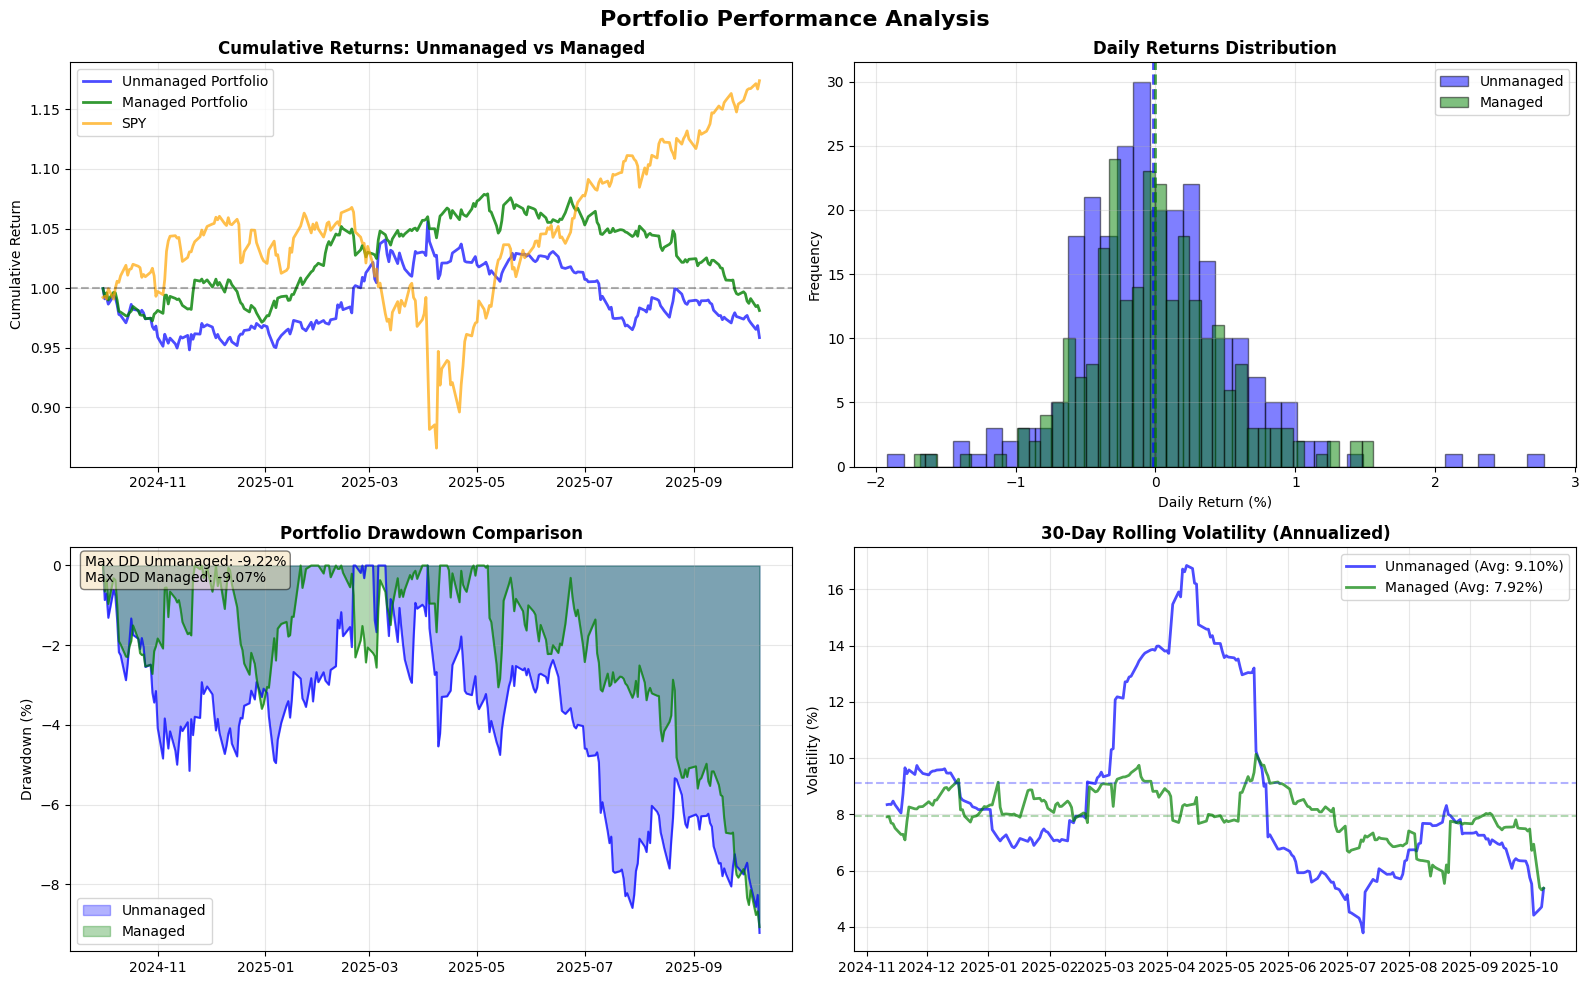

In [6]:
# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Portfolio Performance Analysis', fontsize=16, fontweight='bold')

# 1. Cumulative returns - Portfolio vs Managed vs SPY
ax1 = axes[0, 0]
portfolio_cumulative = (1 + portfolio_daily_returns).cumprod()
managed_cumulative = (1 + managed_daily_returns).cumprod()

ax1.plot(portfolio_cumulative.index, portfolio_cumulative.values, 
         linewidth=2, color='blue', label='Unmanaged Portfolio', alpha=0.7)
ax1.plot(managed_cumulative.index, managed_cumulative.values, 
         linewidth=2, color='green', label='Managed Portfolio', alpha=0.8)

if "SPY" in ticker_closes:
    spy_cumulative = (1 + spy_returns).cumprod()
    aligned_spy = spy_cumulative.reindex(portfolio_cumulative.index).ffill()
    ax1.plot(portfolio_cumulative.index, aligned_spy.values, 
             linewidth=2, color='orange', label='SPY', alpha=0.7)

ax1.set_title('Cumulative Returns: Unmanaged vs Managed', fontweight='bold')
ax1.set_ylabel('Cumulative Return')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.axhline(y=1.0, color='black', linestyle='--', alpha=0.3)

# 2. Daily returns distribution - Comparison
ax2 = axes[0, 1]
ax2.hist(portfolio_daily_returns.dropna() * 100, bins=40, alpha=0.5, 
         color='blue', edgecolor='black', label='Unmanaged')
ax2.hist(managed_daily_returns.dropna() * 100, bins=40, alpha=0.5, 
         color='green', edgecolor='black', label='Managed')
ax2.axvline(portfolio_daily_returns.mean() * 100, color='blue', 
            linestyle='--', linewidth=2, alpha=0.7)
ax2.axvline(managed_daily_returns.mean() * 100, color='green', 
            linestyle='--', linewidth=2, alpha=0.7)
ax2.set_title('Daily Returns Distribution', fontweight='bold')
ax2.set_xlabel('Daily Return (%)')
ax2.set_ylabel('Frequency')
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3. Drawdown chart - Comparison
ax3 = axes[1, 0]
running_max = portfolio_cumulative.cummax()
drawdown = (portfolio_cumulative / running_max - 1.0) * 100
managed_running_max = managed_cumulative.cummax()
managed_drawdown = (managed_cumulative / managed_running_max - 1.0) * 100

ax3.fill_between(drawdown.index, drawdown.values, 0, 
                  alpha=0.3, color='blue', label='Unmanaged')
ax3.plot(drawdown.index, drawdown.values, linewidth=1.5, color='blue', alpha=0.7)
ax3.fill_between(managed_drawdown.index, managed_drawdown.values, 0, 
                  alpha=0.3, color='green', label='Managed')
ax3.plot(managed_drawdown.index, managed_drawdown.values, linewidth=1.5, color='green', alpha=0.7)

ax3.set_title('Portfolio Drawdown Comparison', fontweight='bold')
ax3.set_ylabel('Drawdown (%)')
ax3.grid(True, alpha=0.3)
ax3.legend()
max_dd = drawdown.min()
managed_max_dd = managed_drawdown.min()
ax3.text(0.02, 0.98, f'Max DD Unmanaged: {max_dd:.2f}%\nMax DD Managed: {managed_max_dd:.2f}%', 
         transform=ax3.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Rolling volatility (30-day) - Comparison
ax4 = axes[1, 1]
rolling_vol = portfolio_daily_returns.rolling(window=30).std() * np.sqrt(252) * 100
managed_rolling_vol = managed_daily_returns.rolling(window=30).std() * np.sqrt(252) * 100

ax4.plot(rolling_vol.index, rolling_vol.values, linewidth=2, color='blue', 
         label=f'Unmanaged (Avg: {annual_volatility*100:.2f}%)', alpha=0.7)
ax4.plot(managed_rolling_vol.index, managed_rolling_vol.values, linewidth=2, color='green',
         label=f'Managed (Avg: {managed_annual_volatility*100:.2f}%)', alpha=0.7)
ax4.axhline(y=annual_volatility * 100, color='blue', linestyle='--', alpha=0.3)
ax4.axhline(y=managed_annual_volatility * 100, color='green', linestyle='--', alpha=0.3)
ax4.set_title('30-Day Rolling Volatility (Annualized)', fontweight='bold')
ax4.set_ylabel('Volatility (%)')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()


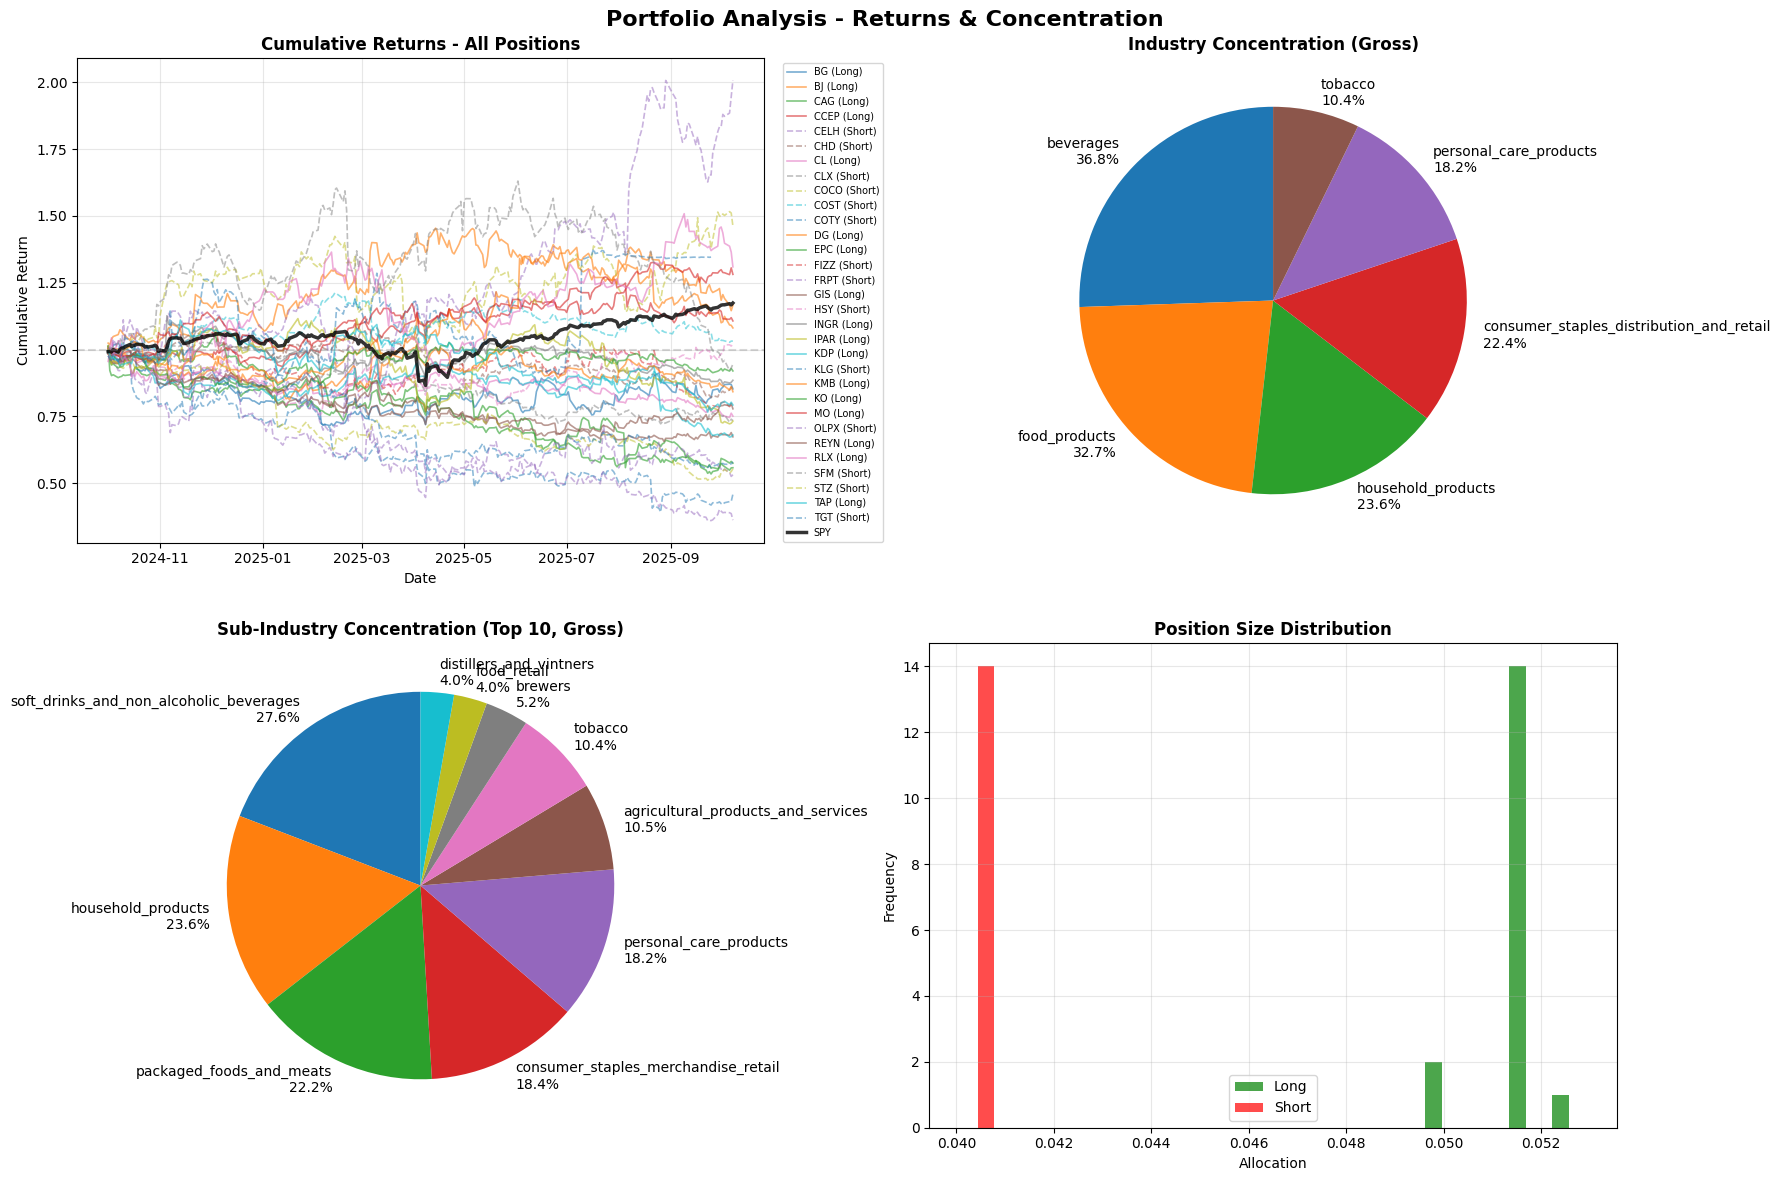

In [7]:
industry_data = {}
sub_industry_data = {}

with MarketSession() as session:
    for ticker in weights.keys():
        ticker_obj = session.query(Ticker).filter(Ticker.ticker == ticker.upper()).first()
        if ticker_obj:
            industry_data[ticker] = ticker_obj.industry
            sub_industry_data[ticker] = ticker_obj.sub_industry

# Calculate concentration by industry and sub-industry
industry_concentration = {}
sub_industry_concentration = {}

for ticker, allocation in weights.items():
    abs_allocation = abs(allocation)
    
    industry = industry_data.get(ticker, 'Unknown')
    if industry:
        industry_concentration[industry] = industry_concentration.get(industry, 0) + abs_allocation
    
    sub_industry = sub_industry_data.get(ticker, 'Unknown')
    if sub_industry:
        sub_industry_concentration[sub_industry] = sub_industry_concentration.get(sub_industry, 0) + abs_allocation

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Portfolio Analysis - Returns & Concentration', fontsize=16, fontweight='bold')

# 1. Cumulative returns of all positions
ax1 = axes[0, 0]
for ticker in sorted(weights.keys()):
    if ticker in ticker_price_returns:
        cumulative_returns = (1 + ticker_price_returns[ticker]).cumprod()
        position_type = portfolio[ticker]['position']
        
        if position_type.lower() == 'short':
            ax1.plot(cumulative_returns.index, cumulative_returns.values, 
                    linestyle='--', alpha=0.5, linewidth=1.2, label=f"{ticker} (Short)")
        else:
            ax1.plot(cumulative_returns.index, cumulative_returns.values, 
                    alpha=0.6, linewidth=1.2, label=f"{ticker} (Long)")

if "SPY" in ticker_closes:
    spy_returns = ReturnsCalculator.daily_price_returns(ticker_closes["SPY"])
    spy_cumulative = (1 + spy_returns).cumprod()
    ax1.plot(spy_cumulative.index, spy_cumulative.values, 
            linewidth=2.5, color='black', label='SPY', alpha=0.8)

ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
ax1.set_title('Cumulative Returns - All Positions', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative Return')
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
ax1.grid(True, alpha=0.3)

# 2. Industry concentration pie chart
ax2 = axes[0, 1]
if industry_concentration:
    labels = [f"{k}\n{v:.1%}" for k, v in sorted(industry_concentration.items(), key=lambda x: x[1], reverse=True)]
    sizes = [v for k, v in sorted(industry_concentration.items(), key=lambda x: x[1], reverse=True)]
    ax2.pie(sizes, labels=labels, autopct='', startangle=90)
    ax2.set_title('Industry Concentration (Gross)', fontweight='bold')

# 3. Sub-industry concentration pie chart
ax3 = axes[1, 0]
if sub_industry_concentration:
    # Limit to top 10 for readability
    sorted_sub = sorted(sub_industry_concentration.items(), key=lambda x: x[1], reverse=True)[:10]
    labels = [f"{k}\n{v:.1%}" for k, v in sorted_sub]
    sizes = [v for k, v in sorted_sub]
    ax3.pie(sizes, labels=labels, autopct='', startangle=90)
    ax3.set_title('Sub-Industry Concentration (Top 10, Gross)', fontweight='bold')

# 4. Position size distribution
ax4 = axes[1, 1]
long_weights = [v for v in weights.values() if v > 0]
short_weights = [abs(v) for v in weights.values() if v < 0]
ax4.hist([long_weights, short_weights], bins=15, label=['Long', 'Short'], alpha=0.7, color=['green', 'red'])
ax4.set_title('Position Size Distribution', fontweight='bold')
ax4.set_xlabel('Allocation')
ax4.set_ylabel('Frequency')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


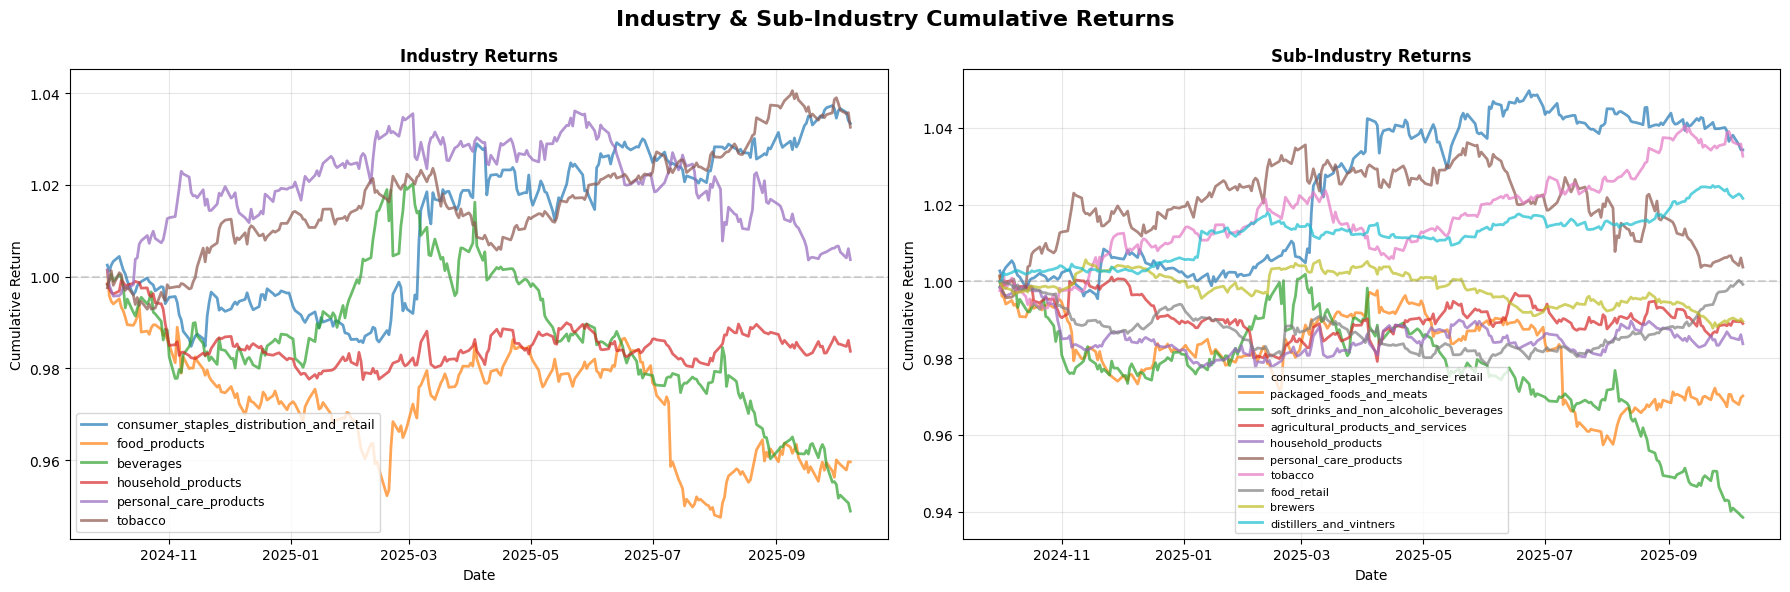

In [8]:
# Calculate industry and sub-industry level returns
# Group tickers by industry
industry_groups = {}
for ticker, allocation in weights.items():
    if ticker in ticker_price_returns:
        industry = industry_data.get(ticker)
        if industry:
            if industry not in industry_groups:
                industry_groups[industry] = {}
            industry_groups[industry][ticker] = allocation

# Group tickers by sub-industry
sub_industry_groups = {}
for ticker, allocation in weights.items():
    if ticker in ticker_price_returns:
        sub_industry = sub_industry_data.get(ticker)
        if sub_industry:
            if sub_industry not in sub_industry_groups:
                sub_industry_groups[sub_industry] = {}
            sub_industry_groups[sub_industry][ticker] = allocation

# Calculate industry-level returns
industry_returns = {}
for industry, tickers_weights in industry_groups.items():
    industry_ticker_returns = {t: ticker_price_returns[t] for t in tickers_weights.keys()}
    industry_daily_returns = PortfolioReturnsCalculator.weighted_daily_returns(
        industry_ticker_returns,
        tickers_weights,
        dropna=False
    )
    industry_returns[industry] = industry_daily_returns

# Calculate sub-industry-level returns
sub_industry_returns = {}
for sub_industry, tickers_weights in sub_industry_groups.items():
    sub_industry_ticker_returns = {t: ticker_price_returns[t] for t in tickers_weights.keys()}
    sub_industry_daily_returns = PortfolioReturnsCalculator.weighted_daily_returns(
        sub_industry_ticker_returns,
        tickers_weights,
        dropna=False
    )
    sub_industry_returns[sub_industry] = sub_industry_daily_returns

# Create two graphs
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Industry & Sub-Industry Cumulative Returns', fontsize=16, fontweight='bold')

# 1. Industry returns
ax1 = axes[0]
for industry, returns in industry_returns.items():
    cumulative_returns = (1 + returns).cumprod()
    ax1.plot(cumulative_returns.index, cumulative_returns.values, 
            linewidth=2, alpha=0.7, label=industry)

ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
ax1.set_title('Industry Returns', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative Return')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. Sub-industry returns
ax2 = axes[1]
for sub_industry, returns in sub_industry_returns.items():
    cumulative_returns = (1 + returns).cumprod()
    ax2.plot(cumulative_returns.index, cumulative_returns.values, 
            linewidth=2, alpha=0.7, label=sub_industry)

ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
ax2.set_title('Sub-Industry Returns', fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Cumulative Return')
ax2.legend(loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Fetching 2 years of prior data: 2022-09-30 to 2024-09-30
Successfully fetched prior data for 32 tickers

PRIOR PERIOD (2022-09-30 to 2024-09-30) PERFORMANCE METRICS
Annualized Return:       -1.97%
Annual Volatility:        8.34%
Sharpe Ratio:             -0.67
Alpha vs SPY:            -4.97%
Beta vs SPY:              -0.03


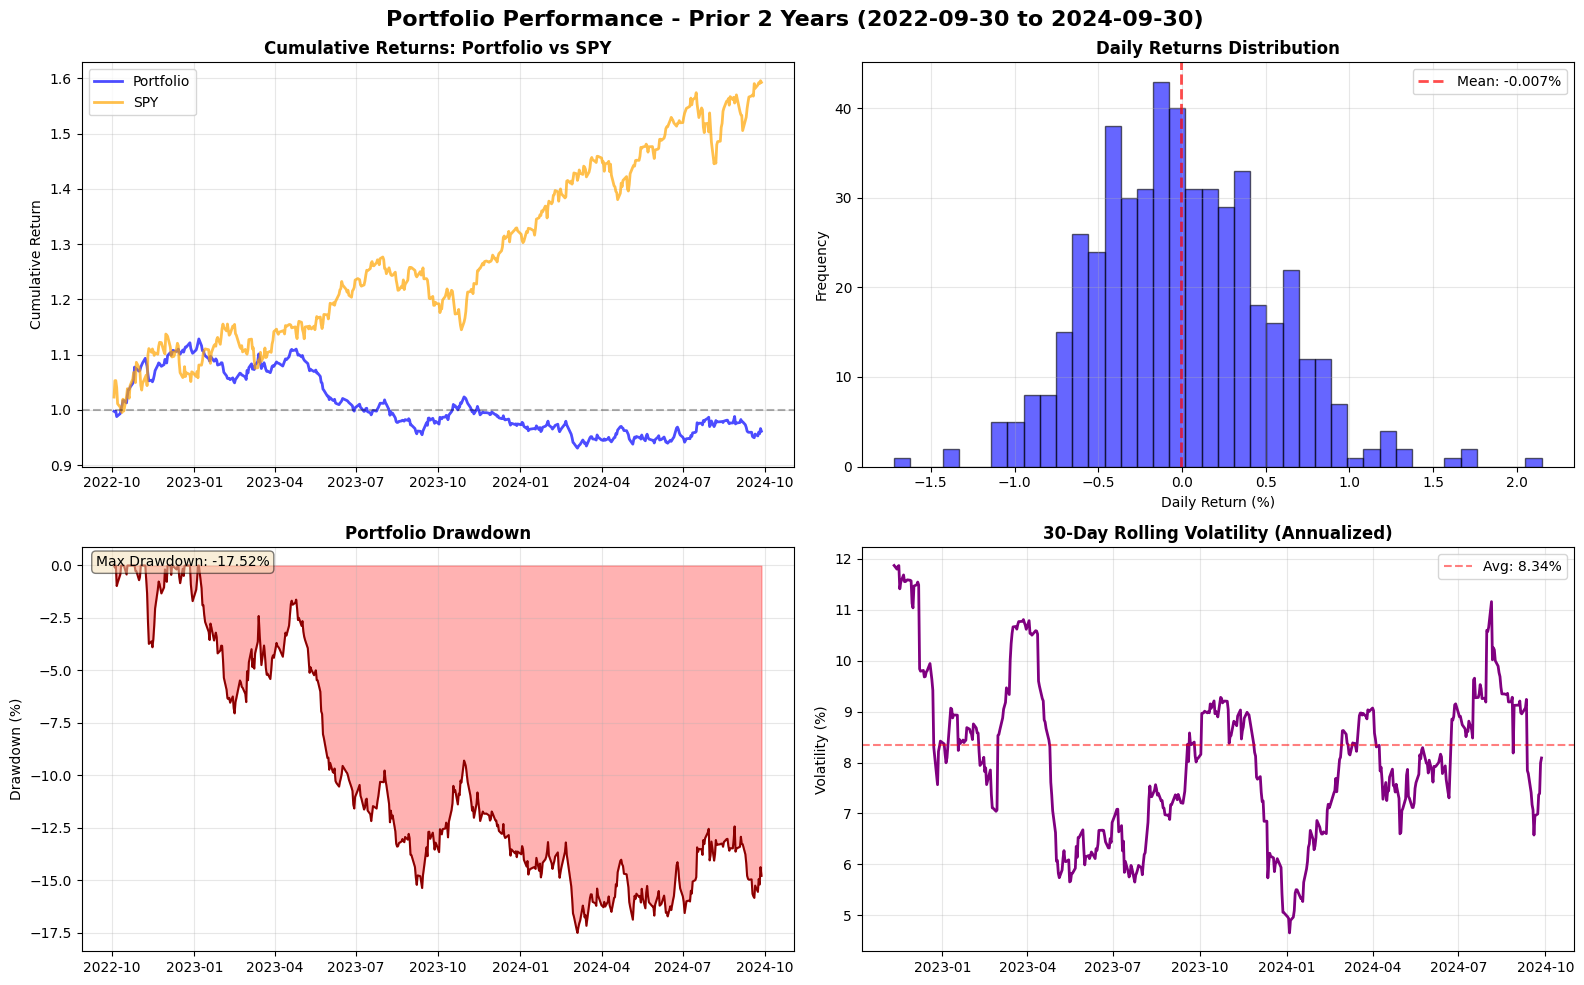

In [9]:
# Graph 2 years of portfolio returns BEFORE the start date
# Start date is 2024-09-30, so we want data from 2022-09-30 to 2024-09-30

prior_start_date = datetime(2022, 9, 30)
prior_end_date = datetime(2024, 9, 30)

prior_start_str = prior_start_date.strftime('%Y-%m-%d')
prior_end_str = prior_end_date.strftime('%Y-%m-%d')

print(f"Fetching 2 years of prior data: {prior_start_str} to {prior_end_str}")

# Fetch bulk price data for the prior period
prior_ticker_closes = fetch_bulk_price_data_for_tickers(
    all_tickers, 
    prior_start_str, 
    prior_end_str, 
    frequency='daily'
)

print(f"Successfully fetched prior data for {len(prior_ticker_closes)} tickers\n")

# Calculate prior period returns
prior_ticker_price_returns = {
    t: ReturnsCalculator.daily_price_returns(prior_ticker_closes[t])
    for t in weights if t in prior_ticker_closes
}

# Calculate portfolio daily returns for prior period
prior_portfolio_daily_returns = PortfolioReturnsCalculator.weighted_daily_returns(
    prior_ticker_price_returns, 
    weights, 
    dropna=False,  
)

# Calculate performance metrics for prior period
prior_annualized_return = ReturnsCalculator.annualized_return(prior_portfolio_daily_returns, trading_days=252)
prior_annual_volatility = RiskCalculator.annualized_volatility(prior_portfolio_daily_returns, trading_days=252)
prior_sharpe_ratio = PerformanceCalculator.sharpe_ratio(
    prior_portfolio_daily_returns, 
    periods_per_year=252
)

# Calculate alpha and beta vs SPY for prior period
if "SPY" in prior_ticker_closes:
    prior_spy_returns = ReturnsCalculator.daily_price_returns(prior_ticker_closes["SPY"])
    prior_alpha = PerformanceCalculator.alpha_jensen(
        prior_portfolio_daily_returns,
        prior_spy_returns,
        periods_per_year=252
    )
    prior_beta = RiskCalculator.beta(
        asset_daily_returns=prior_portfolio_daily_returns,
        market_daily_returns=prior_spy_returns
    )
else:
    prior_alpha = np.nan
    prior_beta = np.nan

# Print prior period metrics
print("=" * 60)
print("PRIOR PERIOD (2022-09-30 to 2024-09-30) PERFORMANCE METRICS")
print("=" * 60)
print(f"Annualized Return:     {prior_annualized_return:>8.2%}")
print(f"Annual Volatility:     {prior_annual_volatility:>8.2%}")
print(f"Sharpe Ratio:          {prior_sharpe_ratio:>8.2f}")
print(f"Alpha vs SPY:          {prior_alpha:>8.2%}")
print(f"Beta vs SPY:           {prior_beta:>8.2f}")
print("=" * 60)

# Plot prior period cumulative returns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Portfolio Performance - Prior 2 Years (2022-09-30 to 2024-09-30)', fontsize=16, fontweight='bold')

# 1. Cumulative returns - Portfolio vs SPY
ax1 = axes[0, 0]
prior_portfolio_cumulative = (1 + prior_portfolio_daily_returns).cumprod()

ax1.plot(prior_portfolio_cumulative.index, prior_portfolio_cumulative.values, 
         linewidth=2, color='blue', label='Portfolio', alpha=0.7)

if "SPY" in prior_ticker_closes:
    prior_spy_cumulative = (1 + prior_spy_returns).cumprod()
    aligned_spy = prior_spy_cumulative.reindex(prior_portfolio_cumulative.index).ffill()
    ax1.plot(prior_portfolio_cumulative.index, aligned_spy.values, 
             linewidth=2, color='orange', label='SPY', alpha=0.7)

ax1.set_title('Cumulative Returns: Portfolio vs SPY', fontweight='bold')
ax1.set_ylabel('Cumulative Return')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.axhline(y=1.0, color='black', linestyle='--', alpha=0.3)

# 2. Daily returns distribution
ax2 = axes[0, 1]
ax2.hist(prior_portfolio_daily_returns.dropna() * 100, bins=40, alpha=0.6, 
         color='blue', edgecolor='black')
ax2.axvline(prior_portfolio_daily_returns.mean() * 100, color='red', 
            linestyle='--', linewidth=2, alpha=0.7, label=f'Mean: {prior_portfolio_daily_returns.mean()*100:.3f}%')
ax2.set_title('Daily Returns Distribution', fontweight='bold')
ax2.set_xlabel('Daily Return (%)')
ax2.set_ylabel('Frequency')
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3. Drawdown chart
ax3 = axes[1, 0]
prior_running_max = prior_portfolio_cumulative.cummax()
prior_drawdown = (prior_portfolio_cumulative / prior_running_max - 1.0) * 100

ax3.fill_between(prior_drawdown.index, prior_drawdown.values, 0, 
                  alpha=0.3, color='red')
ax3.plot(prior_drawdown.index, prior_drawdown.values, linewidth=1.5, color='darkred')

ax3.set_title('Portfolio Drawdown', fontweight='bold')
ax3.set_ylabel('Drawdown (%)')
ax3.grid(True, alpha=0.3)
prior_max_dd = prior_drawdown.min()
ax3.text(0.02, 0.98, f'Max Drawdown: {prior_max_dd:.2f}%', 
         transform=ax3.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Rolling volatility (30-day)
ax4 = axes[1, 1]
prior_rolling_vol = prior_portfolio_daily_returns.rolling(window=30).std() * np.sqrt(252) * 100

ax4.plot(prior_rolling_vol.index, prior_rolling_vol.values, linewidth=2, color='purple')
ax4.axhline(y=prior_annual_volatility * 100, color='red', linestyle='--', alpha=0.5, 
            label=f'Avg: {prior_annual_volatility*100:.2f}%')
ax4.set_title('30-Day Rolling Volatility (Annualized)', fontweight='bold')
ax4.set_ylabel('Volatility (%)')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()